In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import random
from collections import Counter
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
epochs=20
batch_size=32
lr=1e-3

conv1_channels=32
conv2_channels=64
dropout=0.3
fc_hidden=128
arch="baseline"

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class baselineCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super(baselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.fc_hidden = fc_hidden
        self.num_classes = num_classes

        self.fc1 = None
        self.fc2 = None

    def _init_fc(self, x):
        flatten_dim = x.view(x.size(0), -1).shape[1]
        self.fc1 = nn.Linear(flatten_dim, self.fc_hidden).to(x.device)
        self.fc2 = nn.Linear(self.fc_hidden, self.num_classes).to(x.device)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        if self.fc1 is None:
            self._init_fc(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class residualCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.block1 = ResidualBlock(conv1_channels, conv1_channels, stride=1)
        self.block2 = ResidualBlock(conv1_channels, conv2_channels, stride=2)
        self.block3 = ResidualBlock(conv2_channels, conv2_channels, stride=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(conv2_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class resnetTinyCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        c3 = max(conv2_channels, conv1_channels * 2)
        self.stem = nn.Sequential(
            nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(conv1_channels, conv1_channels, stride=1),
            ResidualBlock(conv1_channels, conv1_channels, stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(conv1_channels, conv2_channels, stride=2),
            ResidualBlock(conv2_channels, conv2_channels, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(conv2_channels, c3, stride=2),
            ResidualBlock(c3, c3, stride=1),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(c3, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class skipConcatCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(conv2_channels),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)
        self.fuse = nn.Sequential(
            nn.Conv2d(conv1_channels + conv2_channels, conv2_channels, kernel_size=1),
            nn.BatchNorm2d(conv2_channels),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(conv2_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool1(x1)
        x2 = self.enc2(x2)
        x2 = self.pool2(x2)

        x1_ds = F.adaptive_avg_pool2d(x1, output_size=x2.shape[-2:])
        x = torch.cat([x1_ds, x2], dim=1)
        x = self.fuse(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


def _build_cnn_model(
    arch,
    num_channels,
    num_classes,
    conv1_channels,
    conv2_channels,
    dropout,
    fc_hidden,
):
    if arch == "residual":
        return residualCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    if arch == "resnet":
        return resnetTinyCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    if arch == "skip_concat":
        return skipConcatCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    return baselineCNN(
        num_channels=num_channels,
        num_classes=num_classes,
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        fc_hidden=fc_hidden,
    )

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [5]:
data = np.load("E:/CoDaS Project/Radar/C3_RP_dataset.npz", allow_pickle=True)
X = data["data"]
Y = data["labels"]

le = LabelEncoder()
y_encoded = le.fit_transform(Y)
num_classes = len(le.classes_)
print(f"\nLoaded dataset: {X.shape[0]} samples, shape {X.shape[1:]}, classes: {le.classes_}")


Loaded dataset: 181 samples, shape (39, 128, 128), classes: ['E01' 'E02' 'E03' 'E04' 'E05' 'E06']


In [6]:
train_x, test_x, train_y, test_y = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Train set: {train_x.shape[0]} samples, Test set: {test_x.shape[0]} samples")

class_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

train_ds = TensorDataset(torch.tensor(train_x, dtype=torch.float32), torch.tensor(train_y))
test_ds = TensorDataset(torch.tensor(test_x, dtype=torch.float32), torch.tensor(test_y))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size)

Train set: 144 samples, Test set: 37 samples


In [7]:
#model = timm.create_model("edgenext_small.usi_in1k", num_classes=num_classes)
#model.stem[0] = nn.Conv2d(39, 48, kernel_size=4, stride=4)
#model.to(device)

model = _build_cnn_model(
        arch=arch,
        num_channels=X.shape[1],
        num_classes=num_classes,
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        fc_hidden=fc_hidden,
    ).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {arch}, Parameters: {count_parameters(model)}")

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Model: baseline, Parameters: 29760



=== TRAINING START ===



=== WINDOW-LEVEL PERFORMANCE ===
              precision    recall  f1-score   support

         E01       0.50      0.17      0.25         6
         E02       0.27      0.67      0.38         6
         E03       0.00      0.00      0.00         7
         E04       0.40      0.33      0.36         6
         E05       0.30      0.50      0.38         6
         E06       0.33      0.17      0.22         6

    accuracy                           0.30        37
   macro avg       0.30      0.31      0.27        37
weighted avg       0.29      0.30      0.26        37

window-level accuracy: 0.2973
window-level balanced accuracy: 0.3056


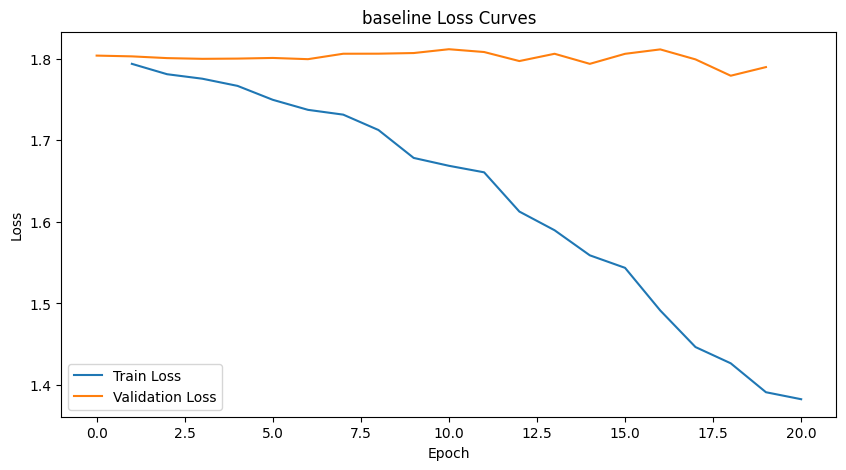

In [8]:
train_loss_history = []
val_loss_history = []
print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss_history.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    val_loss_history.append(val_loss / len(test_loader))
    #print(f"epoch {epoch+1}/{epochs}, train_loss={total_loss / len(train_loader):.4f}, val_loss={val_loss / len(test_loader):.4f}")
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{arch} Loss Curves")
plt.legend()
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

acc_window = accuracy_score(all_true, all_preds)
bal_acc_window = balanced_accuracy_score(all_true, all_preds)
print("\n=== WINDOW-LEVEL PERFORMANCE ===")
report_labels = list(range(num_classes))
print(
    classification_report(
        all_true,
        all_preds,
        labels=report_labels,
        target_names=le.classes_,
        zero_division=0,
    )
)
print(f"window-level accuracy: {acc_window:.4f}")
print(f"window-level balanced accuracy: {bal_acc_window:.4f}")